In [1]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data

In [2]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4897, 3)
Next slips shape (4897, 8)
orig shape (5150, 8)


In [3]:
# Predicting the typical time gap between each event
median_ttns = y_train.median() #Finding the typical inter-event time gap
y_predicted_median =[median_ttns]*len(y_test) #Median predicition for each event in the list
MAE_median = mean_absolute_error(y_test, y_predicted_median) #Comparing how the median prediction comapares to the ML methods using mean absolute error
Median_Error = MAE_median 
y_test_secs_median = y_test #Taking it out of log scale
y_pred_secs_median = [y for y in y_predicted_median]

absolute_error_secs_median = np.abs(y_pred_secs_median - y_test_secs_median)
print("MAE for Median:", np.mean(absolute_error_secs_median))

# Presistence baseline; assuming the TTNS is the same as the previous one
# Using an array where the first column is the TTNS from the previous event and the second column is the actual TTNS for the that event
y_test_array = y_test.values
y_predicted_presist = y_test_array[:-1]
y_actual = y_test_array[1:]

MAE_presist = mean_absolute_error(y_actual, y_predicted_presist)
Presist_Error = MAE_presist
print("MAE for Presistent:", Presist_Error)


Median_RMSE = root_mean_squared_error(y_test, y_predicted_median)
Median_Error = Median_RMSE
print("Median RMSE Error:", Median_Error)

Presist_RMSE = root_mean_squared_error(y_test[1:], y_predicted_presist)
Presist_Error = Presist_RMSE
print("Presist RMSE Error:", Presist_Error)

MAE for Median: 17167.98979591837
MAE for Presistent: 22803.309499489274
Median RMSE Error: 20686.381833644733
Presist RMSE Error: 28630.18221041267


In [ ]:
#Checking different lag values for predictive capeabilites:
lag = 182

y_test_array = y_test
y_predicted_presist = y_test_array[:-lag]
y_actual = y_test_array[lag:]

MAE_presist = mean_absolute_error(y_actual, y_predicted_presist)
Presist_Error = MAE_presist
print("MAE for Presistent:", Presist_Error)

#Checking the full range of numbers: 
best_lag = None
best_error = float("inf")

for lag in range(1,183):

    y_pred = y_test[:-lag]
    y_true = y_test[lag:]

    error = mean_absolute_error(y_true, y_pred)

    if error < best_error:
        best_error = error
        best_lag = lag

print("Best lag:", best_lag)
print("Best MAE:", best_error)


MAE for Presistent: 23842.34962406015
Best lag: 149
Best MAE: 21531.49819494585


: 

Sample0: True = 62055.00s, Predicted = 55095.00s, Error=6960.00s
Sample1: True = 47415.00s, Predicted = 55095.00s, Error=7680.00s
Sample2: True = 81675.00s, Predicted = 55095.00s, Error=26580.00s
Sample3: True = 45660.00s, Predicted = 55095.00s, Error=9435.00s
Sample4: True = 89415.00s, Predicted = 55095.00s, Error=34320.00s
Sample5: True = 85755.00s, Predicted = 55095.00s, Error=30660.00s
Sample6: True = 67920.00s, Predicted = 55095.00s, Error=12825.00s
Sample7: True = 88380.00s, Predicted = 55095.00s, Error=33285.00s
Sample8: True = 42345.00s, Predicted = 55095.00s, Error=12750.00s
Sample9: True = 38445.00s, Predicted = 55095.00s, Error=16650.00s
Sample10: True = 84930.00s, Predicted = 55095.00s, Error=29835.00s
Sample11: True = 50460.00s, Predicted = 55095.00s, Error=4635.00s
Sample12: True = 51510.00s, Predicted = 55095.00s, Error=3585.00s
Sample13: True = 49875.00s, Predicted = 55095.00s, Error=5220.00s
Sample14: True = 50955.00s, Predicted = 55095.00s, Error=4140.00s
Sample15: Tr

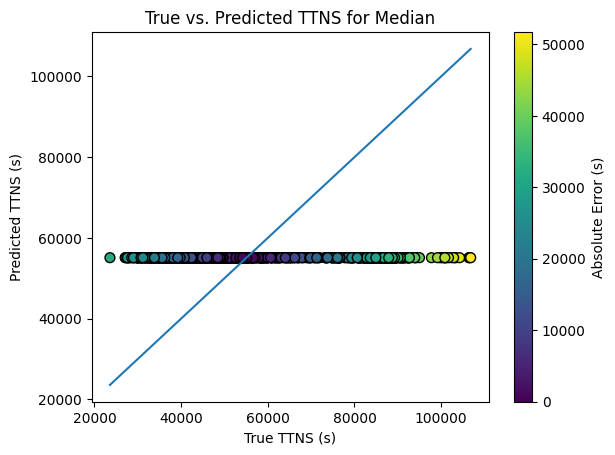

Sample0: True = 47415.00s, Predicted = 62055.00s, Error=14640.00s
Sample1: True = 81675.00s, Predicted = 47415.00s, Error=34260.00s
Sample2: True = 45660.00s, Predicted = 81675.00s, Error=36015.00s
Sample3: True = 89415.00s, Predicted = 45660.00s, Error=43755.00s
Sample4: True = 85755.00s, Predicted = 89415.00s, Error=3660.00s
Sample5: True = 67920.00s, Predicted = 85755.00s, Error=17835.00s
Sample6: True = 88380.00s, Predicted = 67920.00s, Error=20460.00s
Sample7: True = 42345.00s, Predicted = 88380.00s, Error=46035.00s
Sample8: True = 38445.00s, Predicted = 42345.00s, Error=3900.00s
Sample9: True = 84930.00s, Predicted = 38445.00s, Error=46485.00s
Sample10: True = 50460.00s, Predicted = 84930.00s, Error=34470.00s
Sample11: True = 51510.00s, Predicted = 50460.00s, Error=1050.00s
Sample12: True = 49875.00s, Predicted = 51510.00s, Error=1635.00s
Sample13: True = 50955.00s, Predicted = 49875.00s, Error=1080.00s
Sample14: True = 101115.00s, Predicted = 50955.00s, Error=50160.00s
Sample15:

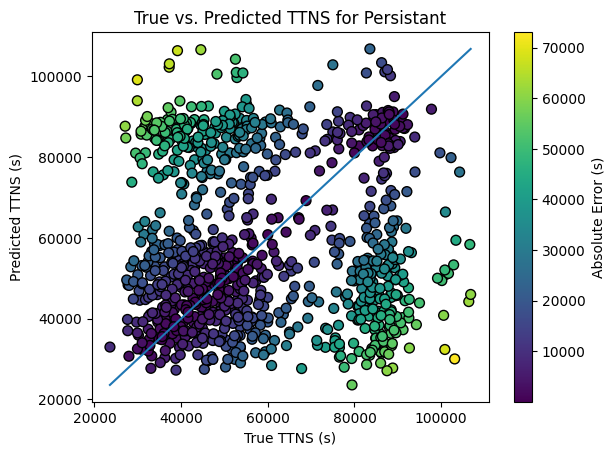

In [5]:
# Baseline Analysis:Median

y_test_secs = y_test #Taking it out of log scale
y_pred_secs = y_predicted_median

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Median")
plt.show()

#Persistnat 
y_test_secs = y_test[1:] #Taking it out of log scale
y_pred_secs = y_predicted_presist

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Persistant")
plt.show()